## Real Example application of Semi-Supervised GMM

This is the application of our code to the Gastrointestinal Lesions in Regular Colonoscopy dataset that can be found [here](https://archive.ics.uci.edu/dataset/408/gastrointestinal+lesions+in+regular+colonoscopy).

In [8]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from data.real_example.preprocessing import load_data_binary
from utils.real_example.evaluation import _em_impute, evaluate_imputers, visualize_evaluation_results, test_gmm_normality_assumptions


X, y_groundtruth, y_experts = load_data_binary(data_file='data\\real_example\\data.csv', gt_file='data\\real_example\\ground_truth.xlsx')

# 1. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Reduction to 10 Dimensions

In [9]:
# 2. Apply PCA (Retaining )
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance= {pca.explained_variance_ratio_.sum()} \n")

Explained variance= 0.7341834791542607 



In [10]:
results_df = evaluate_imputers(X_pca, y_experts, y_groundtruth)
results_df.to_csv("results\\real_example\\10_d\\10d_metrics_results.csv")

# # Display a quick summary
results_df

,Accuracy,Recall_Class_0,Recall_Class_1,Precision_Class_1,F1_Class_1,TP,FP,TN,FN,Pi_Estimated,Pi_Empirical,Pi_Diff_Class_1
Imputer,,,,,,,,,,,,
Mode Imputer,0.763158,0.285714,0.945455,0.776119,0.852459,52,15,6,3,0.795455,0.881579,0.071770
KNN Imputer (k=5),0.881579,0.761905,0.927273,0.910714,0.918919,51,5,16,4,0.736842,0.736842,0.013158
Random Forest Imputer,0.815789,0.523810,0.927273,0.836066,0.879310,51,10,11,4,0.802632,0.802632,0.078947
EM-GMM Imputer,0.763158,0.285714,0.945455,0.776119,0.852459,52,15,6,3,0.881579,0.881579,0.157895


--- Multivariate Normality Diagnostic ---

Analyzing Cluster 0 (n=9)


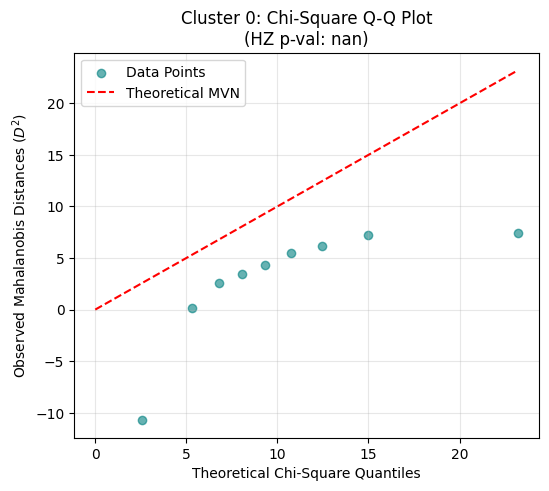


Analyzing Cluster 1 (n=67)


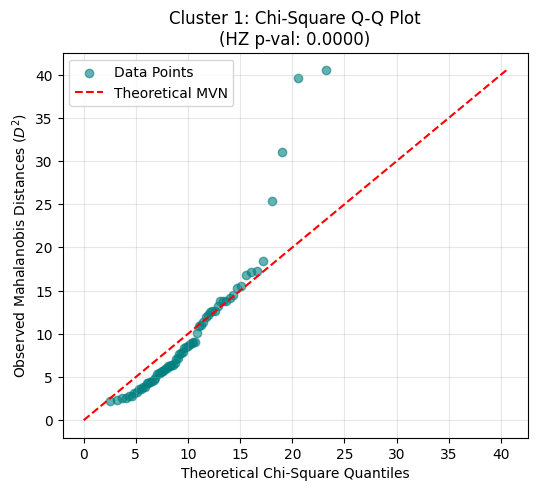

   Cluster  Samples    HZ_P-Value  Is_Normal
0        0        9           NaN      False
1        1       67  6.335929e-68      False


In [11]:
y_pred, _ = _em_impute(X_pca, y_experts)
normality_report = test_gmm_normality_assumptions(X_pca, y_pred)
print(normality_report)

### Reduction to 2 Dimensions

In [21]:
# 2. Apply PCA (Retaining )
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance= {pca.explained_variance_ratio_.sum()} \n")

Explained variance= 0.35862098627157923 



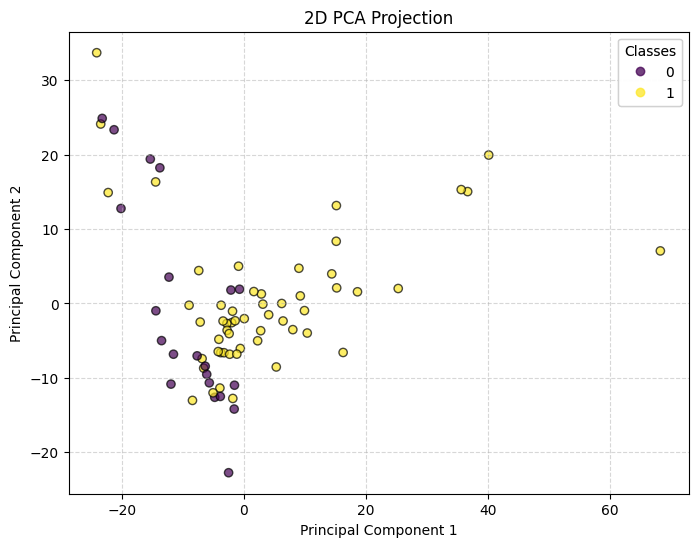

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_pca is your (N, 3) numpy array and y_groundtruth is your (N,) array

plt.figure(figsize=(8, 6))

# Scatter plot using the first two columns: X_pca[:, 0] and X_pca[:, 1]
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_groundtruth, cmap='viridis', alpha=0.7, edgecolor='k')

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection')

# Add a legend for the classes
# We extract the unique classes to build the legend
legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
results_df = evaluate_imputers(X_pca, y_experts, y_groundtruth)
results_df.to_csv("results\\real_example\\3_d\\3d_metrics_results.csv")

# # Display a quick summary
results_df

,Accuracy,Recall_Class_0,Recall_Class_1,Precision_Class_1,F1_Class_1,TP,FP,TN,FN,Pi_Estimated,Pi_Empirical,Pi_Diff_Class_1
Imputer,,,,,,,,,,,,
Mode Imputer,0.763158,0.285714,0.945455,0.776119,0.852459,52,15,6,3,0.795455,0.881579,0.071770
KNN Imputer (k=5),0.789474,0.428571,0.927273,0.809524,0.864407,51,12,9,4,0.828947,0.828947,0.105263
Random Forest Imputer,0.802632,0.476190,0.927273,0.822581,0.871795,51,11,10,4,0.815789,0.815789,0.092105
EM-GMM Imputer,0.697368,0.523810,0.763636,0.807692,0.785047,42,10,11,13,0.702012,0.684211,0.021672


--- Multivariate Normality Diagnostic ---

Analyzing Cluster 0 (n=24)


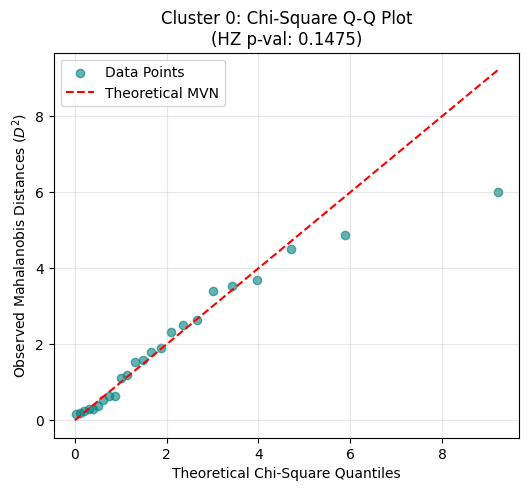


Analyzing Cluster 1 (n=52)


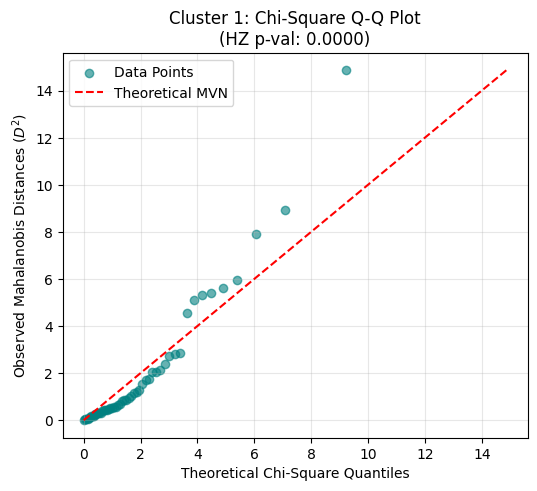

   Cluster  Samples    HZ_P-Value  Is_Normal
0        0       24  1.474971e-01       True
1        1       52  3.369299e-08      False


In [24]:
y_pred, _ = _em_impute(X_pca, y_experts)
normality_report = test_gmm_normality_assumptions(X_pca, y_pred)
print(normality_report)